# Logic Network

In [1]:
import random
from vpython import graph, gcurve, color
import numpy as np
import math
import heapq
#T = time
class Gate:
    def __init__(self, A, B, X, gate_type):
        self.A = A
        self.B = B
        self.X = X
        self.gate_type = gate_type #0 = nand, 1=nor

        if self not in A.drives:
            A.drives.append(self)
        if self not in B.drives:
            B.drives.append(self)
        X.driven_by = self  # this gate drives X
# NOR Gate https://www.futurlec.com/74LS/74LS02.shtml ( Max 10-18) around 14 ns
#NAND Gate https://www.futurlec.com/74LS/74LS00.shtml ( Max 10-15) around 12.5 ns
    def delay(self):
        if self.gate_type == 0:
            T = 12.5
        else:
            T = 14
        return T
        
    def logic(self):
        if self.gate_type == 0:
            return int(not(self.A.get() and self.B.get())) #NAND
        else:
            return int(not(self.A.get() or self.B.get())) #NOR
        return self.X

class Net:
    def __init__(self, name, value): 
        self.name = name
        self.value = value
        self.driven_by = None
        self.drives = []
        self.history = [(0, value)]
    def get(self):
        return self.value
    def set(self, value, t=None):
        self.value = value
        if t is not None:
            self.history.append((t, value))
        

class Event:
    def __init__(self,net,value,T):
        self.net = net
        self.value = value
        self.T = T
    def __lt__(self, other):
        return self.T < other.T # priority queue sorts by time

def post_event(queue, net, value, T):
    heapq.heappush(queue, Event(net, value, T))

def simulate(event_queue):
    while event_queue:
        e = heapq.heappop(event_queue)      # get earliest event
        # skip if value hasn't changed
        if e.net.get() == e.value:
            continue
        # update the net
        e.net.set(e.value, t=e.T)
        print(f"t={e.T}ns | {e.net.name} = {e.value}")
        # only update gates driven by this net
        for gate in e.net.drives:
            new_val = gate.logic()
            new_time = e.T + gate.delay()
            post_event(event_queue, gate.X, new_val, new_time)

def plot_signals_vpython(nets, end_time):
    colors = [color.blue, color.red, color.green, 
              color.orange, color.purple, color.cyan]

    for i, net in enumerate(nets):
        g1 = graph(
            width=600, 
            height=150, 
            title=net.name,
            xtitle="Time (ns)", 
            ytitle="Value"
        )
        gc1 = gcurve(
            graph=g1, 
            color=colors[i % len(colors)], 
            label=net.name
        )

        # square wave - plot old value just before each transition
        prev_val = net.history[0][1]
        gc1.plot(pos=(0, prev_val))

        for t, val in net.history[1:]:
            gc1.plot(pos=(t, prev_val))  # hold old value until transition
            gc1.plot(pos=(t, val))       # jump to new value
            prev_val = val

        gc1.plot(pos=(end_time, prev_val))  # extend to end
            
# NAND = Gate(1,0,0)
# NOR = Gate(0,0,1)




#NAND Propagation
#######################
#single NAND Gate
X = Net("X",0)
Y = Net("Y",0)
Z = Net("Z",1)
NAND = Gate(X,Y,Z,0)

event_queue1 = []
post_event(event_queue1, X, 0, 0)
post_event(event_queue1, Y, 0, 0)
post_event(event_queue1, X, 1, 20)
post_event(event_queue1, X, 0, 40)
post_event(event_queue1, Y, 1, 40)
post_event(event_queue1, X, 1, 60)

simulate(event_queue1)
plot_signals_vpython([X, Y, Z], end_time=80)


######################
#3 NAND Gates
A = Net("A",0)
B = Net("B",0)
C = Net("C",0)
D = Net("D",1)
E = Net("E",1) #C statrts at 0,0
F = Net("F",0)
A_NAND = Gate(A,B,D,0)
B_NAND = Gate(C,C,E,0)
C_NAND = Gate(D,E,F,0)

event_queue2 = []
post_event(event_queue2, A, 1, 0)
post_event(event_queue2, B, 1, 5) #B high at 5 ns
post_event(event_queue2, C, 1, 10) #C high at 10 ns

simulate(event_queue2)
plot_signals_vpython([A, B, C, D, E, F], end_time=50)



#NOR Propagation
######################
#Single NOR Gate
J = Net("J",0)
K = Net("K",0)
L = Net("L",1) #start as 1
NOR = Gate(J,K,L,1)

event_queue3 = []
post_event(event_queue3, J, 0, 0)
post_event(event_queue3, K, 0, 0)
post_event(event_queue3, J, 1, 20)
post_event(event_queue3, J, 0, 40)
post_event(event_queue3, K, 1, 40)
post_event(event_queue3, J, 1, 60)

simulate(event_queue3)
plot_signals_vpython([J, K, L], end_time=80)


###############
#3 NOR Gates
M = Net("M",0)
N = Net("N",0)
O = Net("O",0)
P = Net("P",1)
Q = Net("Q",1) #Q start as 1
R = Net("R",0)
A_NOR = Gate(M,N,P,1)
B_NOR = Gate(O,O,Q,1)
C_NOR = Gate(P,Q,R,1)

event_queue4 = []
post_event(event_queue4, M, 1, 0)
post_event(event_queue4, N, 1, 5) #B high at 5 ns
post_event(event_queue4, O, 1, 10) #C high at 10 ns

simulate(event_queue4)
plot_signals_vpython([M, N, O, P, Q, R], end_time=50)




################
#D-latch
Data = Net("Data",0)
En = Net("Enable",0)
N1 = Net("N1",0) #nand 1 output
N2 = Net("N2",0) #nand 2 output
I = Net("I",0)
I_macron = Net("Ī",0)
NAND1 = Gate(Data,En,N1,0)
NAND2 = Gate(N1,Data,N2,0)
NAND3 = Gate(N1,I_macron,I,0)
NAND4 = Gate(I,N2,I_macron,0)

event_queue5 = []
post_event(event_queue5, Data, 1, 0)
post_event(event_queue5, En, 1, 10) 
post_event(event_queue5, En, 0, 30)
post_event(event_queue5, Data,  0, 40)

simulate(event_queue5)
plot_signals_vpython([Data, En, N1, N2, I, I_macron], end_time=60)

C:\Users\there\anaconda3\envs\myenv\lib\site-packages\vpython\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


<IPython.core.display.Javascript object>

t=20ns | X = 1
t=40ns | Y = 1
t=40ns | X = 0
t=52.5ns | Z = 0
t=52.5ns | Z = 1
t=60ns | X = 1
t=72.5ns | Z = 0
t=0ns | A = 1
t=5ns | B = 1
t=10ns | C = 1
t=17.5ns | D = 0
t=22.5ns | E = 0
t=30.0ns | F = 1
t=20ns | J = 1
t=34ns | L = 0
t=40ns | K = 1
t=40ns | J = 0
t=60ns | J = 1
t=0ns | M = 1
t=5ns | N = 1
t=10ns | O = 1
t=14ns | P = 0
t=24ns | Q = 0
t=38ns | R = 1
t=0ns | Data = 1
t=10ns | Enable = 1
t=12.5ns | N1 = 1
t=12.5ns | N2 = 1
t=22.5ns | N1 = 0
t=25.0ns | I = 1
t=25.0ns | Ī = 1
t=25.0ns | N2 = 0
t=30ns | Enable = 0
t=35.0ns | N2 = 1
t=37.5ns | Ī = 0
t=40ns | Data = 0
t=42.5ns | N1 = 1


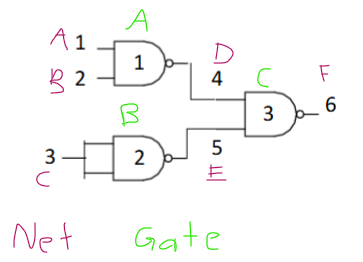

Verification explanation: Using NOR and NAND Truth tables, I can verify the single outputs, For NAND it is only low when both inputs are 1. Nor is only high when both inputs are 0. 

Here are the truth tables: 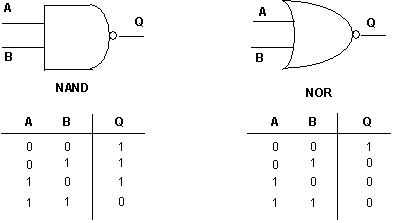

Comparing the truth tables to the graphs and the event queue show that the NOR and NAND gates work perfectly. To also verify, I can calculate the time it takes from the first input being high to the final output being high or low depending on what the gate or combonation of gate does.

For a single NAND Gate:
X goes HIGH  t=20ns + 12.5ns = 32.5ns  (Z changes)
X goes LOW   t=40ns + 12.5ns = 52.5ns  (Z changes)
Y goes HIGH  t=40ns + 12.5ns = 52.5ns  (Z changes)
X goes HIGH  t=60ns + 12.5ns = 72.5ns  (Z changes)

For a single NOR Gate: 
J goes HIGH  t=20ns + 14ns = 34ns  (L changes)
J goes LOW   t=40ns + 14ns = 54ns  (L changes)
K goes HIGH  t=40ns + 14ns = 54ns  (L changes)
J goes HIGH  t=60ns + 14ns = 74ns  (L changes)

3-Gate NAND Network:
B goes HIGH  t=5ns  + 12.5ns = 17.5ns  (D changes)
C goes HIGH  t=10ns + 12.5ns = 22.5ns  (E changes)
D goes LOW   t=17.5ns + 12.5ns = 30ns  (F changes)

3-Gate NOR Network:
M goes HIGH  t=0ns  + 14ns = 14ns  (P changes)
O goes HIGH  t=10ns + 14ns = 24ns  (Q changes)
Q goes LOW   t=24ns + 14ns = 38ns  (R changes)

Comparing this to the other graphs I can safely assume the verification works

Verification of the NAND Latch
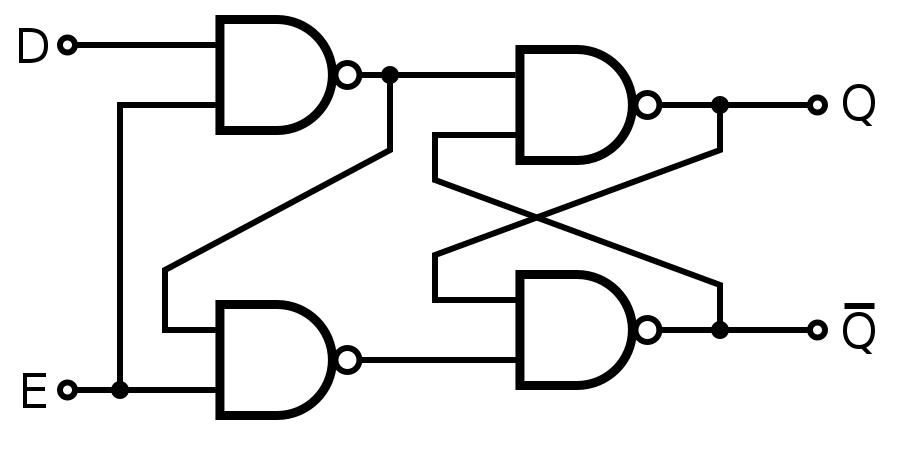

truth table: 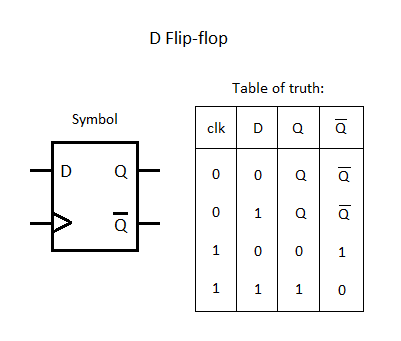

As you can see from the graphs in terms of instance, when both Data and Enable are high, and in that instance, I is high, then I_macron is low as the graphs can see that they it turns low, when both inputs are low and that current output is 1. As for the timing verification it looks something like this which can lbe verified through the results as printed and form the graph: 

Data goes HIGH    t=0ns  + 12.5ns = 12.5ns  (N1 changes)
En goes HIGH   t=5ns  + 12.5ns = 17.5ns  (N2 changes)
N1 goes LOW    t=12.5ns + 12.5ns = 25ns  (I changes)
I goes HIGH    t=25ns + 12.5ns = 37.5ns  (I_macron changes)

Part 4: Experience/results of simulating combo vs sequence circuits:
For traditional combo circuits, it was easier to verify as the inputs and outputs are expected as it doesn't rely on information after the gate has been past so a simple truth table is can verify easily. There is no initial state to worry about except for when the gate needs to start at 1. It was also a lot less glitchy compared to sequential at least in terms of timing. Sequential circuits are harder to verify as it depends on clock cycles and while there is no direct setup before, to get th desired verification inputing certain inputs with appropriate timing was very annoying, until I got it. The timing glitches were also more prevalent especially since bad timing results in completely wrong latch values especially over the clk. 